In [4]:
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['mofc','lofc','hp','dlPFC','FFA/PPA']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

conditions = np.array(['pre_age','pre_category','current_age','current_category'])
index = pd.MultiIndex.from_product([subject_inds, mask_names, conditions], names=['subject', 'mask_name', 'condition'])
df_scores = pd.DataFrame(index=index, columns=['score', 'chance_score'])


for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
    #print("The current subject is %s" % current_subject)
    data_dir = f'/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/'
    all_beta = f"{data_dir}/sub-{current_subject:02}_state.nii.gz"
    datasets = {"mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/mofc_bin.nii.gz"],
                "lofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/lofc_bin.nii.gz"],
                "hp":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/hp_bin.nii.gz"],
                #"dlPFC":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/dlPFC_bin.nii.gz"],
                "dlPFC":[f"/home/garlicseed/Mount/final/beta/dlpfc_bin2.nii.gz"],
                "FFA/PPA":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/FFA-PPA_bin.nii.gz"],
                #"R_mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/R_mofc_bin.nii.gz"]
               }
    labels = pd.read_csv('/home/garlicseed/Mount/final/beta/state_events.tsv',sep='\t')
    
    if current_subject == 21:
            all_beta = f"{data_dir}/sub-{current_subject:02}_state_missing.nii.gz"
            labels = pd.read_csv('/home/garlicseed/Mount/final/beta/sub-21/sub-21_state_events.tsv',sep='\t')
    
    labels_run = labels['run']
    #categories = labels['state'].unique()
    session_labels = labels_run
    state_beta = nb.load(all_beta)

    for mask_name in tqdm_notebook(mask_names):
        print("The current subject is %s, Working on  %s" % (current_subject, mask_name))
        mask_filename = datasets[mask_name][0]
        masker = NiftiMasker(
            mask_img=mask_filename,
            standardize="zscore_sample",
            runs=session_labels,
            smoothing_fwhm=4,
            t_r=1.5,
            memory="nilearn_cache",
            memory_level=1,
                 )
        fmri_masked = masker.fit_transform(state_beta)
    
        for condition in tqdm_notebook(conditions):
            print("current condition is on %s" % condition)
            labels_stim = labels[condition]
            from sklearn.preprocessing import LabelEncoder
            encoder = LabelEncoder()
            condi = encoder.fit_transform(labels_stim)
        
        
            from sklearn.model_selection import LeaveOneGroupOut
            logo = LeaveOneGroupOut()                        
            from sklearn.svm import SVC
            from sklearn.model_selection import cross_val_score
            from sklearn.dummy import DummyClassifier
            from sklearn.metrics import accuracy_score
            pipeline = Pipeline(
                [
                    ("anova", SelectKBest(f_classif, k='all')),
                    #('scaler', StandardScaler()),
                    ("svc", SVC(kernel='linear',C=0.001)),
                ]
            )
            performance_svc = []
            performance_dummy = []
            for train_idx, test_idx in logo.split(fmri_masked, condi, session_labels):
                X_train, X_test = fmri_masked[train_idx, :], fmri_masked[test_idx, :]
                y_train, y_test = condi[train_idx], condi[test_idx]
                pipeline.fit(X_train, y_train)
                dummy = DummyClassifier()
                dummy.fit(X_train, y_train)
                # 在每次迭代中对测试集进行预测，并将预测结果保存到列表中
                y_pred = pipeline.predict(X_test)
                y_pred = np.squeeze(y_pred)
                performance_svc.append(accuracy_score(y_test, y_pred))

                y_pred_dummy = dummy.predict(X_test)
                y_pred_dummy = np.squeeze(y_pred_dummy)
                performance_dummy.append(accuracy_score(y_test, y_pred_dummy)) 
            # 对所有迭代的预测结果进行平均，以得到最终的预测结果
            y_pred_final_svc = np.mean(performance_svc, axis=0)
            y_pred_final_dummy = np.mean(performance_dummy, axis=0)
            df_scores.loc[(current_subject, mask_name, condition), 'score'] = y_pred_final_svc
            df_scores.loc[(current_subject, mask_name, condition), 'chance_score'] = y_pred_final_dummy
        
            print("Scores: %1.2f +- %1.2f" % (np.mean(performance_svc), np.std(performance_svc)))
            print("Chacne Scores: %1.2f +- %1.2f" % (np.mean(performance_dummy), np.std(performance_dummy)))            

df_scores = df_scores.reset_index()            
df_mean = df_scores.groupby(['mask_name', 'condition'])[['score', 'chance_score']].mean()            
df_mean = df_mean.reset_index()    
df_scores.to_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
df_scores.to_csv('/media/garlicseed/data/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')


  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

The current subject is 1, Working on  mofc


  0%|          | 0/4 [00:00<?, ?it/s]

current condition is on pre_age
Scores: 0.59 +- 0.09
Chacne Scores: 0.50 +- 0.00
current condition is on pre_category
Scores: 0.47 +- 0.03
Chacne Scores: 0.50 +- 0.00
current condition is on current_age
Scores: 0.53 +- 0.09
Chacne Scores: 0.50 +- 0.00
current condition is on current_category
Scores: 0.56 +- 0.10
Chacne Scores: 0.50 +- 0.00
The current subject is 1, Working on  lofc


...

current condition is on pre_age
Scores: 0.56 +- 0.06
Chacne Scores: 0.50 +- 0.00
current condition is on pre_category
Scores: 0.53 +- 0.07
Chacne Scores: 0.50 +- 0.00
current condition is on current_age
Scores: 0.17 +- 0.05
Chacne Scores: 0.50 +- 0.00
current condition is on current_category
Scores: 0.59 +- 0.03
Chacne Scores: 0.50 +- 0.00
The current subject is 30, Working on  dlPFC


  0%|          | 0/4 [00:00<?, ?it/s]

current condition is on pre_age
Scores: 0.42 +- 0.09
Chacne Scores: 0.50 +- 0.00
current condition is on pre_category
Scores: 0.52 +- 0.12
Chacne Scores: 0.50 +- 0.00
current condition is on current_age
Scores: 0.52 +- 0.08
Chacne Scores: 0.50 +- 0.00
current condition is on current_category
Scores: 0.53 +- 0.09
Chacne Scores: 0.50 +- 0.00
The current subject is 30, Working on  FFA/PPA


  0%|          | 0/4 [00:00<?, ?it/s]

current condition is on pre_age
Scores: 0.52 +- 0.14
Chacne Scores: 0.50 +- 0.00
current condition is on pre_category
Scores: 0.61 +- 0.08
Chacne Scores: 0.50 +- 0.00
current condition is on current_age
Scores: 0.56 +- 0.08
Chacne Scores: 0.50 +- 0.00
current condition is on current_category
Scores: 0.78 +- 0.07
Chacne Scores: 0.50 +- 0.00


current_age-dlPFC : 	 p= 0.0083 mu=0.5321
current_age-FFA/PPA : 	 p= 0.0001 mu=0.5941
current_category-dlPFC : 	 p= 0.0001 mu=0.6238
current_category-FFA/PPA : 	 p= 0.0001 mu=0.8106
pre_age-dlPFC : 	 p= 0.5000 mu=0.5090
pre_age-FFA/PPA : 	 p= 0.1595 mu=0.5153
pre_category-dlPFC : 	 p= 0.0006 mu=0.5460
pre_category-FFA/PPA : 	 p= 0.0001 mu=0.6214


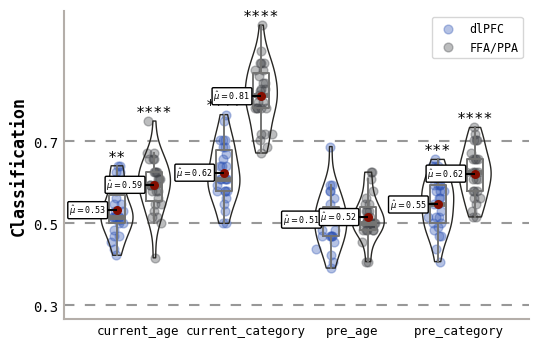

In [5]:
#Plot relevent
import pandas as pd
#df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_relevent/Sorces/accuray.tsv',sep='\t')
import matplotlib.pyplot as plt
from mlxtend.evaluate import permutation_test
from scipy.stats import ttest_1samp
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"

mask_names = ['dlPFC','FFA/PPA']
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(6,4))
jitter_dot = 0.025
jitter = 0.35  # Increase the jitter or separation between mofc and lofc
HLINES = [0.3 , 0.5, 0.7]
COLOR_SCALE = ["#2d52b3", "#404247"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_base = np.full_like(y_data, 0.5)
        #t, p = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data.mean():.4f}')

        ts = ''
        if p < 0.05:
            if p < (0.0001 ):
                ts = '*' * 4
            elif p < (0.001 ):
                ts = '*' * 3
            elif p < (0.01 ):
                ts = '*' * 2
            elif p < (0.05 ):
                ts = '*'
        
        x_data = np.array([i + j * jitter] * len(y_data))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data, s = 40, color=COLOR_SCALE[j], alpha=0.35, label=mask_name if i == 0 else "")
        
        mean_val = y_data.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        if mask_name == "mofc":
            ha = 'left'
            pos = i + j * jitter + 0.1
            ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        else:
            ha = 'right'
            pos = i + j * jitter - 0.1
            ax.plot([pos, i + j * jitter], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 2)), fontsize=6, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data, positions=[i + j * jitter], widths=0.3,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)

        ax.text(i + j * jitter  , np.max(y_data)+0.01, ts, {'fontsize': 11, 'ha': 'center', 'fontweight': 'normal'})
        
# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.2, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=0)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(1.5)
#plt.ylim(0.25, 0.8)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification", size=12, weight="bold")
ax.legend(loc='upper right', fontsize='small')
plt.show()

In [2]:
df_mean#4e5054

,mask_name,condition,score,chance_score
0,FFA/PPA,current_age,0.594097,0.499691
1,FFA/PPA,current_category,0.81061,0.500309
2,FFA/PPA,pre_age,0.515278,0.500309
3,FFA/PPA,pre_category,0.621412,0.499691
4,dlPFC,current_age,0.52963,0.499691
5,dlPFC,current_category,0.620833,0.500309
6,dlPFC,pre_age,0.505401,0.500309
7,dlPFC,pre_category,0.54591,0.499691
8,hp,current_age,0.506559,0.499691
9,hp,current_category,0.558179,0.500309


In [2]:
fmri_masked.shape#406ee3

(64, 9543)

In [6]:
fmri_masked.shape

(64, 6895)